
# LAS (.las) Drillhole Logs → DataFrames & Plots

This notebook scans a folder for LAS files, parses the **~ASCII LOG DATA** section (assumed five columns: **StartDepth, EndDepth, Incline (deg), Azimuth (deg), Gamma (cps)**), converts `-999.25` (or header-defined `NULL`) to missing values, and plots tidy *tracks* for quick QC.

> **Assumptions**
> - Files are LAS 2.x style with a clearly marked `~ASCII LOG DATA` section.
> - The 5 numeric columns are: Start Depth, End Depth, Incline (deg), Azimuth (deg), Gamma Counts Per Second.
> - Depths are in metres. Plots use a downward-increasing depth axis (common in logging).
> - Missing values are represented by `-999.25` unless overridden by the header `NULL.` line.




## Quick start
1. **Set your folder** in the configuration cell below (`DATA_DIR`).
2. Run **all cells**.
3. Use the example cells at the bottom to **plot any hole** or **export combined data**.


In [5]:

# Imports
from pathlib import Path
import re
import io
import pandas as pd
import matplotlib.pyplot as plt

# Display options
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 140)


In [6]:

# === Configuration ===
# Set this to the folder containing your .las files
DATA_DIR = Path("./data/acs")  # change to your folder

# Optional: file pattern (case-insensitive)
FILE_GLOB = "*.las"



## Utilities: LAS parsing
The functions below locate `~ASCII LOG DATA`, read the five columns, and (optionally) parse a few header metadata items like `STRT`, `STOP`, `STEP`, `DATE`, and `NULL`.


In [8]:

ASCII_MARKER = "~ASCII LOG DATA"

HEADER_KEYS = ["STRT", "STOP", "STEP", "NULL", "DATE"]


def _find_ascii_start(lines):
    """Return the index of the line containing '~ASCII LOG DATA' (case-insensitive).
    Raises ValueError if not found."""
    for i, ln in enumerate(lines):
        if ASCII_MARKER in ln.upper():
            return i
    raise ValueError("~ASCII LOG DATA not found in LAS file")


def _parse_null_from_header(lines, default=-999.25):
    """Attempt to read the NULL value from header lines. Fallback to default if not present."""
    for ln in lines:
        up = ln.upper()
        if up.startswith("NULL."):
            # Example format: 'NULL.  -999.25 :NULL VALUE'
            # Extract first number token after 'NULL.'
            rest = ln.split("NULL.", 1)[1]
            # Find first float-like token
            m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", rest)
            if m:
                try:
                    return float(m.group(0))
                except ValueError:
                    pass
    return default


def _parse_header_metadata(lines):
    """Parse a few header fields into a dict for convenience."""
    meta = {}
    for key in HEADER_KEYS:
        pat = re.compile(rf"^{key}\.\s*([^:]+)")
        for ln in lines:
            m = pat.match(ln.strip())
            if m:
                meta[key] = m.group(1).strip()
                break
    return meta


def parse_las_file(path):
    """Parse a LAS file with 5-column ASCII section.

    Returns
    -------
    dict with keys:
      - 'metadata': dict of selected header fields
      - 'df': pandas.DataFrame with columns:
            ['start_depth_m', 'end_depth_m', 'incline_deg', 'azimuth_deg', 'gamma_cps', 'depth_mid_m']
    """
    p = Path(path)
    text = p.read_text(encoding='utf-8', errors='ignore')
    lines = text.splitlines()

    # Locate ASCII section
    idx = _find_ascii_start(lines)

    header_lines = lines[:idx]
    data_lines = lines[idx + 1 :]

    # Determine NULL value
    null_val = _parse_null_from_header(header_lines, default=-999.25)
    meta = _parse_header_metadata(header_lines)
    meta['NULL_RESOLVED'] = null_val

    # Build an in-memory text stream for pandas
    # Filter out blank lines
    data_text = "\n".join([ln for ln in data_lines if ln.strip()])

    # Read 5 whitespace-delimited columns
    col_names = ['start_depth_m', 'end_depth_m', 'incline_deg', 'azimuth_deg', 'gamma_cps']
    df = pd.read_csv(
        io.StringIO(data_text),
        delim_whitespace=True,
        header=None,
        names=col_names,
        na_values=[null_val],
        engine='python'
    )

    # Some LAS writers may occasionally produce rows with >5 tokens due to comments; keep first 5
    if df.shape[1] > 5:
        df = df.iloc[:, :5]
        df.columns = col_names

    # Derived depth for plotting: midpoint of interval
    df['depth_mid_m'] = df[['start_depth_m', 'end_depth_m']].mean(axis=1)

    return {"metadata": meta, "df": df}


def load_all_las(dir_path, pattern="*.las"):
    """Load all LAS files in a folder into a dict keyed by stem (filename without extension)."""
    dir_path = Path(dir_path)
    files = sorted([p for p in dir_path.glob(pattern)])
    out = {}
    for p in files:
        try:
            parsed = parse_las_file(p)
            hole_id = p.stem
            parsed['hole_id'] = hole_id
            out[hole_id] = parsed
        except Exception as e:
            print(f"[WARN] Failed to parse {p.name}: {e}")
    return out



## Load all LAS files in the folder
This scans `DATA_DIR` for `*.las` (change `FILE_GLOB` if needed) and builds a dictionary of parsed results.


In [9]:

parsed = load_all_las(DATA_DIR, FILE_GLOB)
print(f"Parsed files: {len(parsed)}")
list(parsed.keys())[:10]


Parsed files: 31


C:\Users\expg\AppData\Local\Temp\ipykernel_13608\2131959772.py:77: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\expg\AppData\Local\Temp\ipykernel_13608\2131959772.py:77: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\expg\AppData\Local\Temp\ipykernel_13608\2131959772.py:77: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\expg\AppData\Local\Temp\ipykernel_13608\2131959772.py:77: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\expg\AppData\Local\Temp\ipykernel_13608\2131959772.py:77: FutureWarning: Th

['B10_GV_U',
 'B10_GV_U_10',
 'B10_GV_U_15',
 'B10_GV_U_MAX',
 'B11_GV_U',
 'B11_GV_U_10',
 'B11_GV_U_15',
 'B11_GV_U_MAX',
 'B12_GV_U',
 'B12_GV_U_10']


## Preview one hole
Pick any hole ID from the keys above to preview its dataframe and metadata.


In [10]:

# Pick the first hole for a quick peek
if parsed:
    any_hole = next(iter(parsed.keys()))
    any_hole, parsed[any_hole]['metadata']
else:
    print("No LAS files found in DATA_DIR.")


In [11]:

if parsed:
    any_hole = next(iter(parsed.keys()))
    parsed[any_hole]['df'].head(12)



## Plotting utilities
Functions to make standard *tracks* with a common depth axis (inverted so depth increases downward).


In [12]:

from typing import List, Optional


def plot_tracks(df: pd.DataFrame,
                tracks: Optional[List[str]] = None,
                depth_col: str = 'depth_mid_m',
                title: Optional[str] = None,
                figsize=(12, 8)):
    """Plot selected tracks vs depth as side-by-side panels.

    Parameters
    ----------
    df : DataFrame with depth column and numeric tracks
    tracks : list of column names to plot; defaults to ['incline_deg','azimuth_deg','gamma_cps']
    depth_col : name of depth column to use
    title : optional figure title
    figsize : tuple for figure size
    """
    if tracks is None:
        tracks = ['incline_deg', 'azimuth_deg', 'gamma_cps']

    n = len(tracks)
    fig, axes = plt.subplots(1, n, figsize=figsize, sharey=True)
    if n == 1:
        axes = [axes]

    depth = df[depth_col]

    for ax, col in zip(axes, tracks):
        if col not in df.columns:
            ax.text(0.5, 0.5, f"Missing column: {col}", ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue
        ax.plot(df[col], depth, '-', lw=1)
        ax.set_xlabel(col)
        ax.grid(True, which='both', ls='--', alpha=0.4)

    # Depth axis: increase downwards
    axes[0].set_ylabel('Depth (m)')
    axes[0].invert_yaxis()

    if title:
        fig.suptitle(title, y=0.98)

    fig.tight_layout()
    return fig, axes


def plot_hole(parsed_entry, hole_id: Optional[str] = None, tracks=None):
    df = parsed_entry['df']
    ttl = hole_id or parsed_entry.get('hole_id') or ''
    return plot_tracks(df, tracks=tracks, title=f"{ttl}")



## Example: plot the first hole


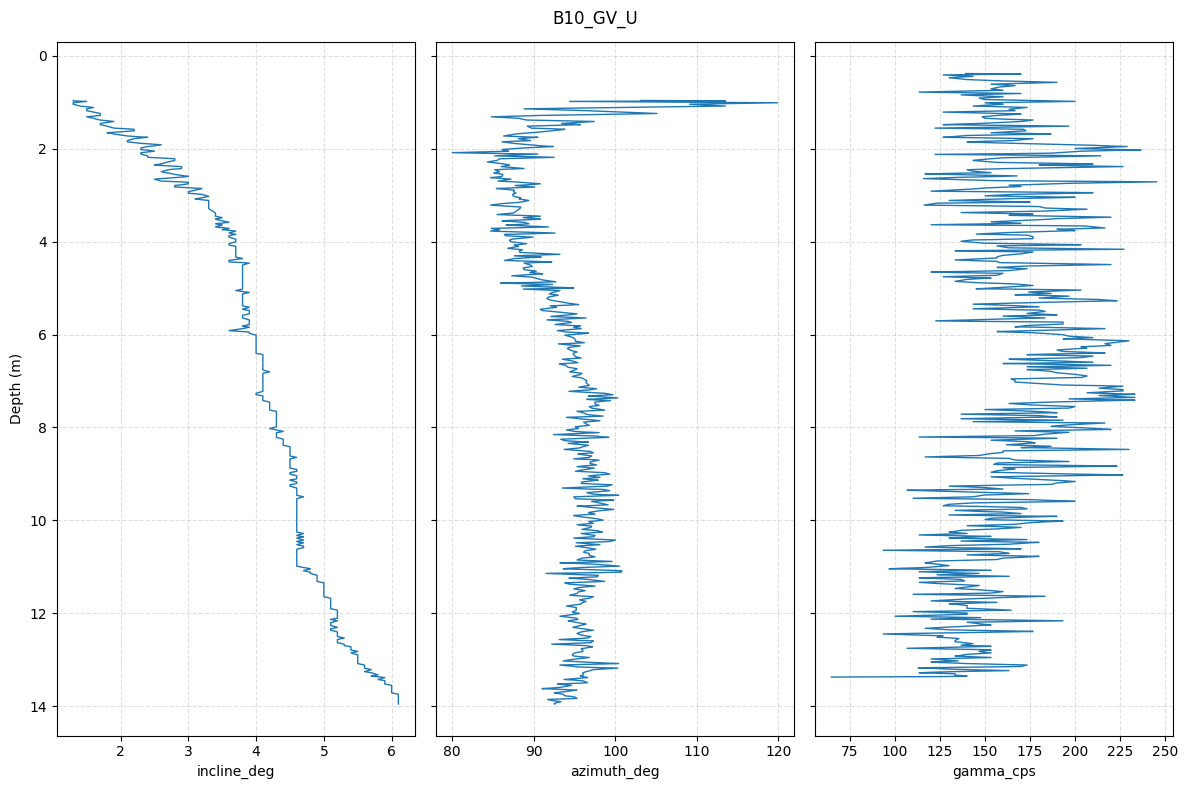

In [13]:

if parsed:
    hid = next(iter(parsed.keys()))
    fig, axes = plot_hole(parsed[hid], hole_id=hid)
    plt.show()



## Combine and export (optional)
Merge all parsed files into a single tidy DataFrame and optionally export to CSV for use elsewhere.


In [ ]:

# Build a combined table with a hole_id column
if parsed:
    frames = []
    for hid, entry in parsed.items():
        df = entry['df'].copy()
        df['hole_id'] = hid
        frames.append(df)
    combined = pd.concat(frames, ignore_index=True)
    display(combined.head())

    # Uncomment to export
    # combined.to_csv('combined_las_logs.csv', index=False)
